# 04. Comparing Causal Models: The Final Showdown

The Mayor is waiting for your final recommendation. Should we ban drivers over 65 based on the original descriptive statistics?

We have learned that data can lie if we don't map the causal relationships. To make our final decision, we will run 4 different statistical models and compare the effect of `Driver_Age` across all of them.

This will be the ultimate showdown between **Machine Learning (Prediction)** and **Econometrics (Causal Inference)**.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import numpy as np
from sklearn.metrics import roc_curve, auc

df = pd.read_csv('smart_city_road_safety_synthetic_5000.csv')
df['Accident_Numeric'] = df['Accident'].astype(int)

## Training the 4 Models

We will train four Logistic Regression models with different feature sets based on our DAGs:

1. **Model 1: Naive (The Mayor's View).** Only uses Age. It ignores the DAG completely.
2. **Model 2: Correct Causal Model.** Uses Age, Vision Quality (adjusting the Confounder), and Weather (adding the Precision Variable). It explicitly ignores Driving Speed.
3. **Model 3: Mediator Bias (The Machine Learning approach).** Uses absolutely everything: Age, Vision, Weather, AND Driving Speed. This is what an automated algorithm like XGBoost would do by default.
4. **Model 4: Collider Bias.** Uses the Correct Model, but trains only on the filtered dataset of people who ended up in the hospital.

In [2]:
mod_naive = smf.logit("Accident_Numeric ~ Driver_Age", data=df).fit(disp=False)
mod_correct = smf.logit("Accident_Numeric ~ Driver_Age + Vision_Quality + C(Weather)", data=df).fit(disp=False)
mod_mediator = smf.logit("Accident_Numeric ~ Driver_Age + Vision_Quality + C(Weather) + Driving_Speed", data=df).fit(disp=False)

df_hospital = df[df['Severe_Hospitalization'] == 1]
mod_collider = smf.logit("Accident_Numeric ~ Driver_Age + Vision_Quality + C(Weather)", data=df_hospital).fit(disp=False)

## The Ultimate Tradeoff: Prediction vs Causation

In traditional Data Science bootcamps, students are taught to maximize a metric called **AUC (Area Under the Receiver Operating Characteristic Curve)**. The higher the AUC, the better the model is at predicting the outcome.

Let's see which of our models is the best at predicting who will crash.

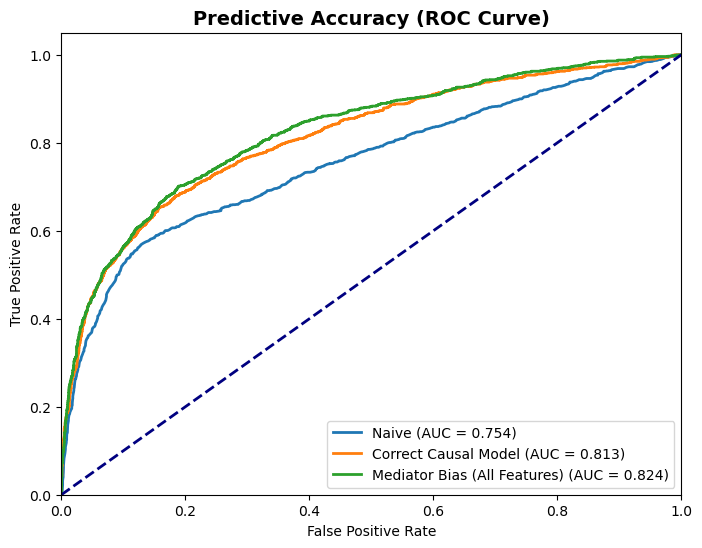

In [3]:
plt.figure(figsize=(8,6))
for name, mod in zip(['Naive', 'Correct Causal Model', 'Mediator Bias (All Features)'], [mod_naive, mod_correct, mod_mediator]):
    fpr, tpr, _ = roc_curve(df['Accident_Numeric'], mod.predict(df))
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Predictive Accuracy (ROC Curve)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.show()

### 🏆 The Machine Learning Winner
**Wow!** The "Mediator Bias" model wins the prediction contest hands down. By throwing every single variable (including speed) into the math, it achieves the highest AUC.

If you work for an **Auto Insurance Company**, this is exactly what you want. You don't care *why* someone crashes; you just want to predict *if* they will crash so you can charge them higher premiums. 

But the Mayor isn't trying to set insurance premiums. The Mayor is trying to set **Public Policy**. The Mayor wants to intervene in the real world to stop accidents. Does the model with the best predictive power give us the right policy answer?

To answer this, we must look at the **Forest Plot**.

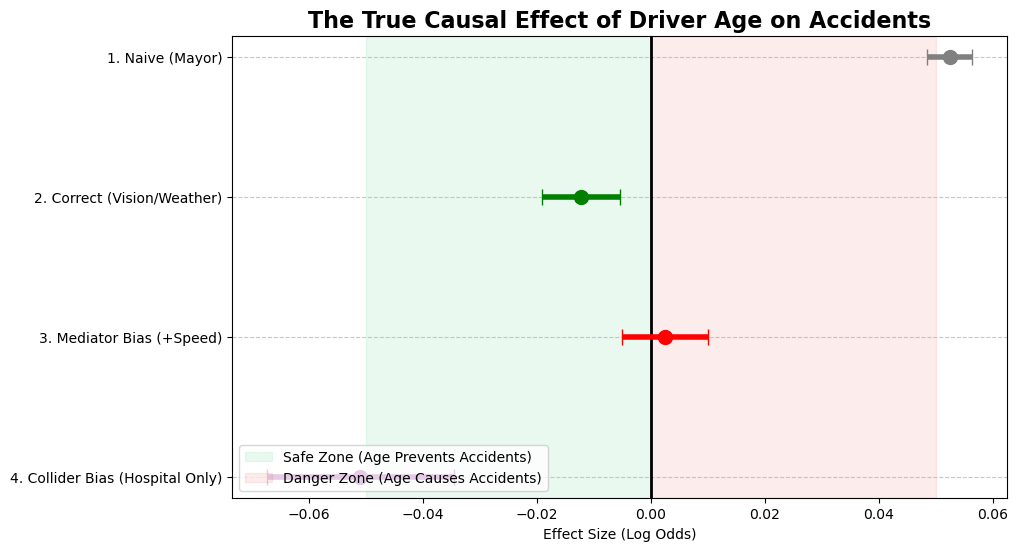

In [4]:
def extract_coef(model, model_name):
    return {
        'Model': model_name,
        'Coefficient': model.params['Driver_Age'],
        'Std_Err': model.bse['Driver_Age']
    }

results = [
    extract_coef(mod_naive, '1. Naive (Mayor)') , 
    extract_coef(mod_correct, '2. Correct (Vision/Weather)'), 
    extract_coef(mod_mediator, '3. Mediator Bias (+Speed)'), 
    extract_coef(mod_collider, '4. Collider Bias (Hospital Only)')
]
results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.axvspan(-0.05, 0, color='#2ecc71', alpha=0.1, label='Safe Zone (Age Prevents Accidents)')
plt.axvspan(0, 0.05, color='#e74c3c', alpha=0.1, label='Danger Zone (Age Causes Accidents)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=2)

colors = ['gray', 'green', 'red', 'purple']
for i, row in results_df.iterrows():
    plt.errorbar(x=row['Coefficient'], y=row['Model'], 
                 xerr=1.96*row['Std_Err'], fmt='o', 
                 color=colors[i], ecolor=colors[i], elinewidth=4, capsize=6, markersize=10)

plt.title("The True Causal Effect of Driver Age on Accidents", fontsize=16, fontweight='bold')
plt.xlabel("Effect Size (Log Odds)")
plt.gca().invert_yaxis() 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower left')
plt.show()

### 📊 How to read a Forest Plot:
- The **dot** is the estimated effect of Age on Accidents.
- The **horizontal line** is the 95% Confidence Interval (our mathematical uncertainty).
- The **black vertical line at zero** is the Null Hypothesis (Age has exactly zero effect).
- If the dot and its line fall entirely in the **Red Zone**, the variable is statistically dangerous.
- If it falls entirely in the **Green Zone**, it is statistically safe.
- If it touches the **Zero Line**, it is statistically insignificant.

## The Final Recommendation

What do we tell the Mayor?

1. **The Naive Model** is heavily in the Danger Zone. It agrees with the Mayor: older age predicts more accidents.
2. **The Mediator Bias Model** is deep in the Danger Zone. Even though it had the highest predictive power (AUC), it gives the **wrong policy answer**. By throwing "Speed" into the model, the algorithm punished the elderly for driving slowly, making them look like massive menaces.
3. **The Collider Bias Model** is in the Green Zone. If we only looked at hospital data, we would make a deadly mistake and conclude old people are magically safer than young people.
4. **The Correct Model** touches the zero line. Once you adjust for Vision Quality (The Confounder) and Weather (The Precision Variable), Age is no longer inherently dangerous. 

---
### **📜 Official Policy Memo:**
**To:** The Mayor's Office
**Subject:** Age vs Accidents Policy Review

Revoking licenses based on age is discriminatory and misses the root cause of the accidents. The statistical spike in accidents among the elderly is caused entirely by declining vision quality, which is masked by their compensatory slow driving.

**Action Required:** 
Do not ban the elderly. Implement mandatory **Vision Tests** for license renewals. You will solve the accident spike without punishing safe elderly drivers who wear their glasses!

---
# 🚀 The Bridge to Uber: Technical Cheatsheet

Congratulations! You have successfully mastered Causal Inference in a Smart City. 
Now, you will be deployed to **Uber** to solve a real-world business experiment regarding the Uber Pool waiting window.

To ensure you don't get stuck on the Python syntax during the workshop, keep these two technical tips in mind:

### 1. The Golden Rule of Business Causal Modeling
Before you write any code, map the business problem on paper:
1. Identify your **Treatment** (The policy you are testing, e.g., 5-min wait time).
2. Identify your **Outcome** (The business metric you want to change, e.g., Driver Payouts).
3. Identify **Confounders** (Contextual variables like Rush Hour that affect both the policy implementation and the outcome). $\rightarrow$ **CONTROL FOR THESE!**
4. Identify **Mediators** (The mechanism by which your policy works, e.g., Getting more Matches). $\rightarrow$ **DO NOT CONTROL FOR THESE!**

### 2. Logit vs OLS (Predicting Probabilities vs Predicting Money)
In this Smart City lab, we used `smf.logit()` (Logistic Regression). Why? Because our outcome was `Accident` (0 = Safe, 1 = Crash). Logistic regression is explicitly designed for binary outcomes.

In the Uber Workshop, your outcome will be `total_driver_payout`, which is **Money**. Money is a continuous variable (it can be $5, $12.50, $100). 

**CRITICAL:** If you try to put a continuous variable into `smf.logit()`, Python will crash! For continuous variables like Money, you must switch back to standard linear regression using `smf.ols()`.

**Example:**
```python
# For Binary Outcomes (Like Accidents)
model = smf.logit("Accident_Numeric ~ Driver_Age", data=df).fit()

# For Continuous Outcomes (Like Money / Payouts)
model = smf.ols("total_driver_payout ~ treat", data=df).fit()
```

Good luck with the Uber Case!